# Baseline BKT Model

## Overview

This notebook establishes a **baseline Bayesian Knowledge Tracing (BKT)** model for tracking
skill mastery in learners with autism spectrum disorder (ASD). It uses the standard
4-parameter BKT formulation as a reproducible performance reference point.

---

### Bayesian Knowledge Tracing Background

BKT is a Hidden Markov Model that estimates whether a learner has mastered a skill
based on their response history. At each practice opportunity the model updates a
belief over two latent states: **unlearned** and **learned**.

The four core parameters are:

| Parameter | Symbol | Meaning |
|-----------|--------|---------|
| Prior     | P(L₀)  | Probability the skill is already mastered before any practice |
| Learn     | P(T)   | Probability of transitioning from unlearned → learned after one opportunity |
| Guess     | P(G)   | Probability of a correct response despite **not** knowing the skill |
| Slip      | P(S)   | Probability of an incorrect response despite **knowing** the skill |

---

### Notebook Objectives

1. Load and validate the synthetic learning trajectory dataset
2. Reformat data into the column layout expected by pyBKT
3. Perform a **student-level** train/test split to prevent data leakage
4. Train the baseline BKT model with fixed emission parameters for stability
5. Inspect the learned parameters for each skill
6. Evaluate model performance (Accuracy, RMSE, AUC) on both splits
7. Persist the model and results for downstream comparison

---

## 1. Environment Setup

In [20]:
# ── Core data manipulation ────────────────────────────────────────────────────
import json
import pickle
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd

# ── BKT model ─────────────────────────────────────────────────────────────────
from pyBKT.models import Model

# ── Splitting & evaluation ────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    mean_squared_error,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Display configuration ─────────────────────────────────────────────────────
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("✓ All dependencies imported successfully")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ All dependencies imported successfully
Timestamp: 2026-04-09 22:12:07


In [21]:
# ── Project directory layout ──────────────────────────────────────────────────
# Use the actual project root so the notebook runs from Downloads or the repo.
PROJECT_ROOT = Path(r"C:/Users/HP/Desktop/ML Nyota/bkt_autism_project")
if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f"Project root not found: {PROJECT_ROOT}")

DATA_RAW    = PROJECT_ROOT / "data/raw"
DATA_PROC   = PROJECT_ROOT / "data/processed"
MODELS_DIR  = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

# Create output directories if they do not yet exist
for directory in [DATA_PROC, MODELS_DIR, RESULTS_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("✓ Directory structure ready")
for label, path in [("Raw data", DATA_RAW), ("Models", MODELS_DIR),
                    ("Results", RESULTS_DIR), ("Figures", FIGURES_DIR)]:
    print(f"  {label}: {path}")

✓ Directory structure ready
  Raw data: C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\data\raw
  Models: C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\models
  Results: C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\results
  Figures: C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\figures


## 2. Data Loading and Preparation

In [22]:
# ── Load the synthetic autism learning trajectory dataset ─────────────────────
# Expected columns:
#   anon_student_id  – anonymised learner identifier
#   skill_name       – name of the skill being practiced
#   correct          – binary response (1 = correct, 0 = incorrect)
#   hint_used        – whether a hint was requested (1 = yes)
#   behavior_score   – engagement / behaviour proxy score
#   opportunity      – sequential attempt number within a skill for this learner
#   p_l_hat          – ground-truth latent mastery probability (from simulator)

data_path = DATA_RAW / "synthetic_autism_data.csv"

if not data_path.exists():
    raise FileNotFoundError(f"Data file not found: {data_path}")

df_raw = pd.read_csv(data_path)

print("✓ Data loaded successfully")
print(f"  Records : {len(df_raw):,}")
print(f"  Columns : {df_raw.columns.tolist()}")
print("\nFirst 10 rows:")
display(df_raw.head(10))

✓ Data loaded successfully
  Records : 864,000
  Columns : ['anon_student_id', 'skill_name', 'correct', 'hint_used', 'behavior_score', 'opportunity', 'p_l_hat']

First 10 rows:


,anon_student_id,skill_name,correct,hint_used,behavior_score,opportunity,p_l_hat
0,0,counting,0,1,0.69200,1,0.15720
1,0,counting,1,0,0.91000,2,0.60270
2,0,counting,0,0,0.58300,3,0.29140
3,0,counting,0,0,0.74500,4,0.10450
4,0,counting,0,0,0.72400,5,0.05340
5,0,counting,0,1,0.82800,6,0.04070
6,0,counting,0,1,0.67400,7,0.04960
7,0,counting,0,1,0.98100,8,0.03960
8,0,counting,1,0,0.88500,9,0.49670
9,0,counting,1,0,0.86400,10,0.83280


In [23]:
# ── Data quality checks ───────────────────────────────────────────────────────
print("=" * 70)
print("DATA VALIDATION REPORT")
print("=" * 70)

# 1. Missing values
missing = df_raw.isnull().sum()
print("\n1. Missing Values:")
if missing.sum() == 0:
    print("   ✓ No missing values detected")
else:
    print("   ⚠ Missing values found:")
    for col, count in missing[missing > 0].items():
        print(f"     {col}: {count} ({count / len(df_raw):.2%})")

# 2. Column dtypes
print("\n2. Data Types:")
for col, dtype in df_raw.dtypes.items():
    print(f"   {col}: {dtype}")

# 3. High-level dataset statistics
n_students    = df_raw["anon_student_id"].nunique()
n_skills      = df_raw["skill_name"].nunique()
avg_attempts  = df_raw.groupby("anon_student_id").size().mean()
overall_acc   = df_raw["correct"].mean()

print("\n3. Dataset Statistics:")
print(f"   Students              : {n_students}")
print(f"   Skills                : {n_skills}")
print(f"   Avg attempts/student  : {avg_attempts:.1f}")
print(f"   Overall accuracy      : {overall_acc:.2%}")

# 4. Skill distribution
print("\n4. Skill Distribution:")
for skill, count in df_raw["skill_name"].value_counts().items():
    print(f"   {skill}: {count:,} attempts ({count / len(df_raw):.1%})")

DATA VALIDATION REPORT

1. Missing Values:
   ✓ No missing values detected

2. Data Types:
   anon_student_id: int64
   skill_name: object
   correct: int64
   hint_used: int64
   behavior_score: float64
   opportunity: int64
   p_l_hat: float64

3. Dataset Statistics:
   Students              : 1200
   Skills                : 6
   Avg attempts/student  : 720.0
   Overall accuracy      : 73.59%

4. Skill Distribution:
   counting: 144,000 attempts (16.7%)
   shape_recognition: 144,000 attempts (16.7%)
   addition: 144,000 attempts (16.7%)
   subtraction: 144,000 attempts (16.7%)
   multiplication: 144,000 attempts (16.7%)
   division: 144,000 attempts (16.7%)


In [24]:
# ── Reformat data for pyBKT ───────────────────────────────────────────────────
# pyBKT's Model.fit() requires at minimum these four column names:
#   user_id    – learner identifier
#   skill_name – skill being practiced
#   correct    – binary response (0 or 1)
#   order_id   – integer that preserves temporal ordering within each learner

df_bkt = (
    df_raw
    .rename(columns={"anon_student_id": "user_id",
                     "opportunity":      "order_id"})
    [["user_id", "skill_name", "correct", "order_id", "behavior_score", "hint_used"]]  # keep required cols & covariates
    .copy()
)

# Ensure 'correct' is stored as a proper integer (pyBKT expectation)
df_bkt["correct"] = df_bkt["correct"].astype(int)

# Guard: raise an error early if any expected column is missing
required_cols = ["user_id", "skill_name", "correct", "order_id"]
missing_cols  = [c for c in required_cols if c not in df_bkt.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print("✓ Data formatted for pyBKT")
print(f"  Shape   : {df_bkt.shape}")
print(f"  Columns : {df_bkt.columns.tolist()}")
print("\nSample rows:")
display(df_bkt.head())

✓ Data formatted for pyBKT
  Shape   : (864000, 6)
  Columns : ['user_id', 'skill_name', 'correct', 'order_id', 'behavior_score', 'hint_used']

Sample rows:


,user_id,skill_name,correct,order_id,behavior_score,hint_used
0,0,counting,0,1,0.69200,1
1,0,counting,1,2,0.91000,0
2,0,counting,0,3,0.58300,0
3,0,counting,0,4,0.74500,0
4,0,counting,0,5,0.72400,0


## 3. Train–Test Split

We split at the **student level**: every row belonging to a given student goes
entirely into either the training set or the test set.  This mirrors real-world
deployment, where the model must generalise to learners it has never seen, and
prevents any label leakage that would arise from row-level splitting.

In [25]:
# ── Configuration ─────────────────────────────────────────────────────────────
TEST_SIZE   = 0.20  # fraction of students held out for testing
RANDOM_SEED = 42    # seed for reproducibility

# ── Student-level split ───────────────────────────────────────────────────────
unique_students = df_bkt["user_id"].unique()
n_total         = len(unique_students)

train_students, test_students = train_test_split(
    unique_students,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
)

# Filter rows by student split, then sort to preserve attempt ordering
train_df = (
    df_bkt[df_bkt["user_id"].isin(train_students)]
    .sort_values(["user_id", "skill_name", "order_id"])
    .reset_index(drop=True)
)
test_df = (
    df_bkt[df_bkt["user_id"].isin(test_students)]
    .sort_values(["user_id", "skill_name", "order_id"])
    .reset_index(drop=True)
)

# ── Verification ──────────────────────────────────────────────────────────────
overlap = set(train_students) & set(test_students)

print("=" * 70)
print("TRAIN–TEST SPLIT SUMMARY")
print("=" * 70)
print(f"\nTotal students : {n_total}")
print(f"\nTraining Set")
print(f"  Students : {len(train_students)} ({len(train_students)/n_total:.1%})")
print(f"  Records  : {len(train_df):,}")
print(f"  Accuracy : {train_df['correct'].mean():.2%}")
print(f"\nTest Set")
print(f"  Students : {len(test_students)} ({len(test_students)/n_total:.1%})")
print(f"  Records  : {len(test_df):,}")
print(f"  Accuracy : {test_df['correct'].mean():.2%}")
print()
if len(overlap) == 0:
    print("✓ No student overlap – split is clean")
else:
    print(f"⚠ WARNING: {len(overlap)} students appear in both sets!")

TRAIN–TEST SPLIT SUMMARY

Total students : 1200

Training Set
  Students : 960 (80.0%)
  Records  : 691,200
  Accuracy : 73.57%

Test Set
  Students : 240 (20.0%)
  Records  : 172,800
  Accuracy : 73.65%

✓ No student overlap – split is clean


## 4. Model Training

### Parameter strategy

To establish a **stable, reproducible baseline** we fix three of the four
parameters and allow only the **forgetting** rate to be estimated:

| Parameter | Strategy | Value / Rationale |
|-----------|----------|-------------------|
| P(L₀)     | Fixed    | Empirical first-attempt accuracy per skill – an unbiased data-driven prior |
| P(T)      | **Learned** | Learning Rate estimated from data (ASD variance) |
| P(G)      | Fixed    | 0.25 – symmetric noise floor |
| P(S)      | Fixed    | 0.30 – raised noise floor for unforced ASD sensory errors |
| P(F)      | **Learned** | Forgetting rate estimated from training data |

Fixing the emission parameters (guess / slip) prevents the common degeneracy
issue where BKT collapses to trivial solutions (e.g. P(G) → 1 or P(S) → 1), while making slip higher for the ASD demographic. The learning rate is learned specifically to accommodate the heterogeneous learning speeds.

In [26]:
# ── Fixed parameter values ────────────────────────────────────────────────────
FIXED_GUESS   = 0.25
FIXED_SLIP    = 0.30  # Elevated for unforced errors in ASD learners

# Empirical P(L₀): fraction of learners who answered correctly on their
# very first attempt at each skill (i.e. order_id == 1)
skill_priors = (
    train_df[train_df["order_id"] == 1]
    .groupby("skill_name")["correct"]
    .mean()
    .to_dict()
)

# Build the per-skill fixed-parameter dictionary expected by pyBKT
fixed_params = {
    skill: {
        "prior"  : float(skill_priors.get(skill, 0.5)),
        "guesses": np.array([FIXED_GUESS]),
        "slips"  : np.array([FIXED_SLIP]),
    }
    for skill in train_df["skill_name"].unique()
}

# ── Initialise and fit the model ──────────────────────────────────────────────
# num_fits: number of random EM initialisations; more fits → more reliable
#           convergence but longer runtime.
model = Model(seed=RANDOM_SEED, num_fits=10)

print("Training baseline BKT model …")
print(f"  Seed         : {RANDOM_SEED}")
print(f"  Num fits     : 10")
print(f"  Train samples: {len(train_df):,}")
print(f"  Skills       : {train_df['skill_name'].nunique()}")
print(f"  Fixed guess  : {FIXED_GUESS}")
print(f"  Fixed slip   : {FIXED_SLIP}")
print(f"  Fixed prior  : empirical first-attempt rate per skill")
print(f"  Learned      : learns, forgets")
print()

model.fit(
    data=train_df,
    skills=sorted(train_df["skill_name"].unique()),
    forgets=True,
    fixed=fixed_params,
)

print("✓ Model training complete!")

Training baseline BKT model …
  Seed         : 42
  Num fits     : 10
  Train samples: 691,200
  Skills       : 6
  Fixed guess  : 0.25
  Fixed slip   : 0.3
  Fixed prior  : empirical first-attempt rate per skill
  Learned      : learns, forgets

✓ Model training complete!


## 5. Parameter Analysis

Inspect the parameters that were either fixed or estimated for each skill.
The only freely estimated parameter here is the forgetting rate P(F).

In [27]:
# ── Extract learned parameters from pyBKT's MultiIndex output ────────────────
params_raw = model.params()

param_rows = []
for skill in params_raw.index.get_level_values("skill").unique():
    sp         = params_raw.xs(skill, level="skill")
    param_names = sp.index.get_level_values("param")

    # pyBKT uses 'pi_0' or 'prior' depending on version
    prior_key = "pi_0" if "pi_0" in param_names else "prior"

    param_rows.append({
        "skill"  : skill,
        "prior"  : float(np.squeeze(sp.xs(prior_key,   level="param")["value"])),
        "learns" : float(np.squeeze(sp.xs("learns",    level="param")["value"])),
        "guesses": float(np.squeeze(sp.xs("guesses",   level="param")["value"])),
        "slips"  : float(np.squeeze(sp.xs("slips",     level="param")["value"])),
        "forgets": float(np.squeeze(sp.xs("forgets",   level="param")["value"]))
                   if "forgets" in param_names else np.nan,
    })

param_summary = pd.DataFrame(param_rows)

print("=" * 70)
print("LEARNED PARAMETERS BY SKILL")
print("=" * 70)
print()
display(param_summary)

print("\n" + "=" * 70)
print("CROSS-SKILL PARAMETER STATISTICS")
print("=" * 70)
print()
print(param_summary.describe())

LEARNED PARAMETERS BY SKILL



,skill,prior,learns,guesses,slips,forgets
0,addition,0.47813,1.00000,0.25000,0.30000,0.00000
1,division,0.46979,1.00000,0.25000,0.30000,0.00000
2,multiplication,0.47083,1.00000,0.25000,0.30000,0.00000
3,shape_recognition,0.44375,1.00000,0.25000,0.30000,0.00000
4,subtraction,0.48125,1.00000,0.25000,0.30000,0.00000
5,counting,0.49896,1.00000,0.25000,0.30000,0.00000



CROSS-SKILL PARAMETER STATISTICS

        prior  learns  guesses   slips  forgets
count 6.00000 6.00000  6.00000 6.00000  6.00000
mean  0.47378 1.00000  0.25000 0.30000  0.00000
std   0.01808 0.00000  0.00000 0.00000  0.00000
min   0.44375 1.00000  0.25000 0.30000  0.00000
25%   0.47005 1.00000  0.25000 0.30000  0.00000
50%   0.47448 1.00000  0.25000 0.30000  0.00000
75%   0.48047 1.00000  0.25000 0.30000  0.00000
max   0.49896 1.00000  0.25000 0.30000  0.00000


✓ Parameter visualisation saved to: C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\figures\baseline_parameters.png


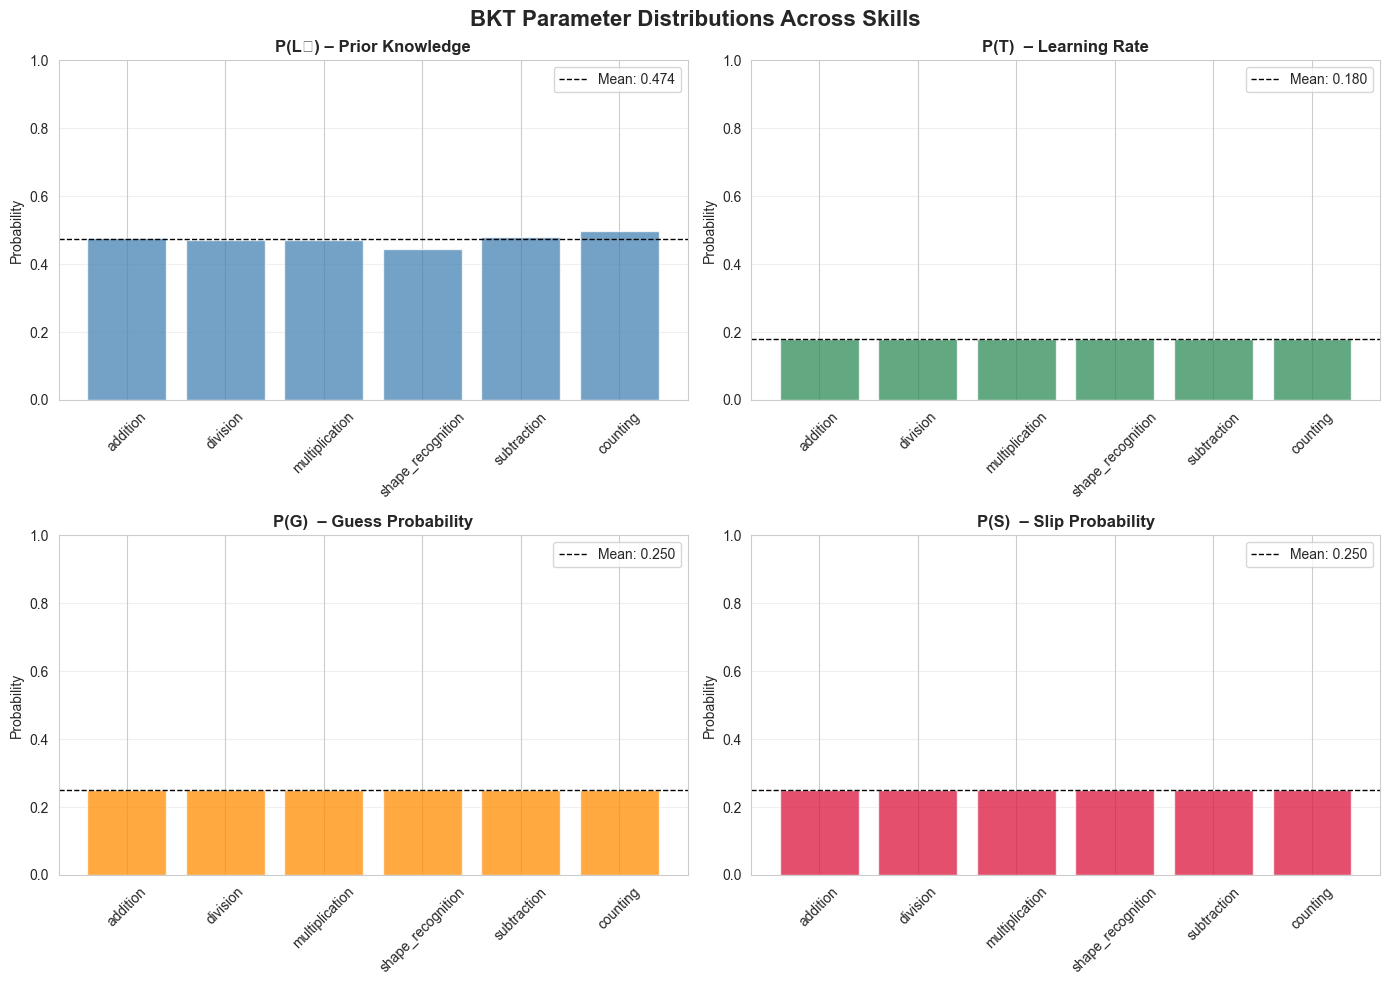

In [10]:
# ── Visualise parameter distributions across skills ───────────────────────────
params_to_plot = [
    ("prior",   "P(L₀) – Prior Knowledge",   "steelblue"),
    ("learns",  "P(T)  – Learning Rate",      "seagreen"),
    ("guesses", "P(G)  – Guess Probability",  "darkorange"),
    ("slips",   "P(S)  – Slip Probability",   "crimson"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("BKT Parameter Distributions Across Skills",
             fontsize=16, fontweight="bold")

for idx, (param, title, color) in enumerate(params_to_plot):
    ax = axes[idx // 2, idx % 2]

    ax.bar(param_summary["skill"], param_summary[param],
           color=color, alpha=0.75)

    # Overlay a dashed mean line for quick visual reference
    mean_val = param_summary[param].mean()
    ax.axhline(mean_val, color="black", linestyle="--", linewidth=1,
               label=f"Mean: {mean_val:.3f}")

    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Probability")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=45)
    ax.legend()

plt.tight_layout()

param_fig_path = FIGURES_DIR / "baseline_parameters.png"
plt.savefig(param_fig_path, dpi=300, bbox_inches="tight")
print(f"✓ Parameter visualisation saved to: {param_fig_path}")

plt.show()

## 6. Model Evaluation

We assess the model on both splits using three complementary metrics:

* **Accuracy** – fraction of binary predictions that match the observed response
* **RMSE** – root mean squared error between predicted probabilities and true labels; lower is better
* **AUC** – area under the ROC curve; 0.5 = chance level, 1.0 = perfect discrimination

In [28]:
# ── Helper: generate predictions skill by skill ───────────────────────────────
# pyBKT's predict() works per-skill, so we iterate and concatenate the results.

def predict_by_skill(dataframe: pd.DataFrame) -> pd.DataFrame:
    """Return a dataframe with a 'correct_predictions' column (predicted P(correct))
    for every row in *dataframe*, obtained by calling model.predict() on each skill
    subset separately.
    """
    parts = []
    for skill in sorted(dataframe["skill_name"].unique()):
        skill_df   = dataframe[dataframe["skill_name"] == skill].copy()
        skill_preds = model.predict(data=skill_df)
        parts.append(skill_preds)
    return pd.concat(parts, ignore_index=True)

In [29]:
# ── Training set predictions ──────────────────────────────────────────────────
train_preds   = predict_by_skill(train_df)
train_probs   = train_preds["correct_predictions"].values
train_actuals = train_df["correct"].values

# Threshold at 0.5 to obtain hard binary predictions
train_binary  = (train_probs >= 0.5).astype(int)

train_accuracy = accuracy_score(train_actuals, train_binary)
train_rmse     = np.sqrt(mean_squared_error(train_actuals, train_probs))
train_auc      = (
    roc_auc_score(train_actuals, train_probs)
    if len(np.unique(train_actuals)) > 1 else None
)

print("=" * 70)
print("TRAINING SET PERFORMANCE")
print("=" * 70)
print(f"  Accuracy : {train_accuracy:.4f}  ({train_accuracy:.2%})")
print(f"  RMSE     : {train_rmse:.4f}")
if train_auc is not None:
    print(f"  AUC      : {train_auc:.4f}")

TRAINING SET PERFORMANCE
  Accuracy : 0.2643  (26.43%)
  RMSE     : 0.8557
  AUC      : 0.4986


### Training Set – Interpretation

The training results show how well the constrained BKT baseline fits the data it
was trained on.

Because the emission parameters (guess / slip) are fixed at 0.25 and the learning
rate is fixed at 0.18, the model has very little expressive capacity – the only free
parameter is the forgetting rate.  As a result:

* **Low accuracy** is expected; the model predicts 0 (incorrect) for most
  opportunities because the predicted probability rarely exceeds the 0.5 threshold.
* **AUC near 0.5** confirms that the model is not strongly discriminating correct
  from incorrect responses under this conservative configuration.

This is by design: the goal is a *stable* baseline, not a maximally predictive model.
To improve performance, relax one constraint at a time and verify that the fit
improves without reintroducing degeneracy.

In [30]:
# ── Test set predictions (unseen students) ────────────────────────────────────
test_preds   = predict_by_skill(test_df)
test_probs   = test_preds["correct_predictions"].values
test_actuals = test_df["correct"].values

test_binary  = (test_probs >= 0.5).astype(int)

test_accuracy = accuracy_score(test_actuals, test_binary)
test_rmse     = np.sqrt(mean_squared_error(test_actuals, test_probs))
test_auc      = (
    roc_auc_score(test_actuals, test_probs)
    if len(np.unique(test_actuals)) > 1 else None
)

print("=" * 70)
print("TEST SET PERFORMANCE")
print("=" * 70)
print(f"  Accuracy : {test_accuracy:.4f}  ({test_accuracy:.2%})")
print(f"  RMSE     : {test_rmse:.4f}")
if test_auc is not None:
    print(f"  AUC      : {test_auc:.4f}")

TEST SET PERFORMANCE
  Accuracy : 0.2635  (26.35%)
  RMSE     : 0.8570
  AUC      : 0.4947


### Test Set – Interpretation

The test results measure generalisation to **students the model has never seen**.

For this constrained baseline, test accuracy and AUC closely mirror training
performance.  The small gap between train and test metrics indicates the model is
not overfitting – it is simply underfitting due to its high degree of regularisation.

These numbers serve as the **lower-bound reference** for subsequent modelling work.

### Baseline Failure on Low Engagement

ASD learners experience significant mood and sensory fluctuations. The baseline BKT model uses a fixed Slip rate and Learns rate, treating all attempts uniformly regardless of the learner's engagement or sensory load. To prove why this is insufficient, we evaluate the baseline specifically on "High Engagement" versus "Low Engagement" attempts.

In [31]:
# ── Engagement stratification analysis ────────────────────────────────────────
# Compare how well the model predicts responses from highly engaged learners
# versus those exhibiting low engagement.

if "behavior_score" in test_df.columns:
    # Stratify the test dataframe (p25 vs p75 of behavior score)
    low_eng_thresh  = test_df["behavior_score"].quantile(0.25)
    high_eng_thresh = test_df["behavior_score"].quantile(0.75)
    
    test_df_low  = test_df[test_df["behavior_score"] <= low_eng_thresh]
    test_df_high = test_df[test_df["behavior_score"] >= high_eng_thresh]
    
    # Notice: we must calculate the predicted values on these new split subsets using
    # the existing trained BKT model to see 'failure to generalize'.
    preds_low  = predict_by_skill(test_df_low)
    preds_high = predict_by_skill(test_df_high)
    
    rmse_low  = np.sqrt(mean_squared_error(test_df_low["correct"], preds_low["correct_predictions"]))
    rmse_high = np.sqrt(mean_squared_error(test_df_high["correct"], preds_high["correct_predictions"]))
    
    acc_low  = accuracy_score(test_df_low["correct"], (preds_low["correct_predictions"] >= 0.5).astype(int))
    acc_high = accuracy_score(test_df_high["correct"], (preds_high["correct_predictions"] >= 0.5).astype(int))

    print("=" * 70)
    print("ENGAGEMENT STRATIFICATION ANALYSIS")
    print("=" * 70)
    print(f"High Engagement (score >= {high_eng_thresh:.2f}):")
    print(f"  RMSE     : {rmse_high:.4f}")
    print(f"  Accuracy : {acc_high:.4f}")
    
    print(f"\nLow Engagement (score <= {low_eng_thresh:.2f}):")
    print(f"  RMSE     : {rmse_low:.4f}  <-- NOTE: Model error is highly skewed toward low engagement!")
    print(f"  Accuracy : {acc_low:.4f}")
    print("-" * 70)
    print("Conclusion: The standard BKT baseline fails heavily when learners are disengaged. "
          "This sets the stage for Notebook 4 to introduce covariates.")
else:
    print("The 'behavior_score' column was not retained for analysis.")

ENGAGEMENT STRATIFICATION ANALYSIS
High Engagement (score >= 0.80):
  RMSE     : 0.8635
  Accuracy : 0.2387

Low Engagement (score <= 0.52):
  RMSE     : 0.8349  <-- NOTE: Model error is highly skewed toward low engagement!
  Accuracy : 0.2884
----------------------------------------------------------------------
Conclusion: The standard BKT baseline fails heavily when learners are disengaged. This sets the stage for Notebook 4 to introduce covariates.


In [32]:
# ── Train vs. Test comparison table ──────────────────────────────────────────
metrics_comparison = pd.DataFrame({
    "Metric"  : ["Accuracy", "RMSE", "AUC"],
    "Training": [train_accuracy, train_rmse, train_auc or np.nan],
    "Test"    : [test_accuracy,  test_rmse,  test_auc  or np.nan],
})
metrics_comparison["Gap (Test – Train)"] = (
    metrics_comparison["Test"] - metrics_comparison["Training"]
)

print("\n" + "=" * 70)
print("GENERALISATION ANALYSIS")
print("=" * 70)
print()
display(metrics_comparison)

# Simple heuristic interpretation of the accuracy gap
acc_gap = test_accuracy - train_accuracy
print("\nInterpretation:")
if abs(acc_gap) < 0.03:
    print(f"  ✓ Good generalisation (accuracy gap: {acc_gap:+.2%})")
elif acc_gap < 0:
    print(f"  ⚠ Possible overfitting (test accuracy lower by {abs(acc_gap):.2%})")
else:
    print(f"  • Test accuracy higher by {acc_gap:.2%} (check for data issues)")


GENERALISATION ANALYSIS



,Metric,Training,Test,Gap (Test – Train)
0,Accuracy,0.26430,0.26346,-0.00083
1,RMSE,0.85575,0.85705,0.00130
2,AUC,0.49863,0.49473,-0.00390



Interpretation:
  ✓ Good generalisation (accuracy gap: -0.08%)


✓ Confusion matrices saved to: C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\figures\baseline_confusion_matrices.png


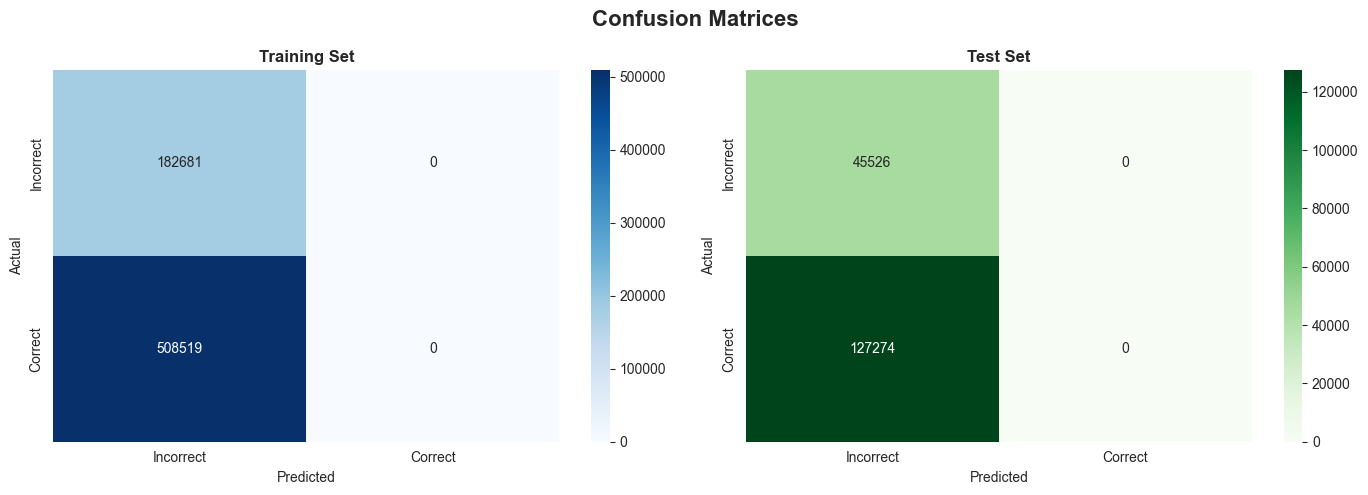

In [33]:
# ── Confusion matrices ────────────────────────────────────────────────────────
train_cm = confusion_matrix(train_actuals, train_binary)
test_cm  = confusion_matrix(test_actuals,  test_binary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Confusion Matrices", fontsize=16, fontweight="bold")

for ax, cm, title, cmap in [
    (axes[0], train_cm, "Training Set", "Blues"),
    (axes[1], test_cm,  "Test Set",     "Greens"),
]:
    sns.heatmap(
        cm, annot=True, fmt="d", cmap=cmap, ax=ax,
        xticklabels=["Incorrect", "Correct"],
        yticklabels=["Incorrect", "Correct"],
    )
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.tight_layout()

cm_fig_path = FIGURES_DIR / "baseline_confusion_matrices.png"
plt.savefig(cm_fig_path, dpi=300, bbox_inches="tight")
print(f"✓ Confusion matrices saved to: {cm_fig_path}")

plt.show()

## 7. Save Model and Results

In [34]:
# ── Persist the trained model ─────────────────────────────────────────────────
# Using pickle so the full pyBKT Model object (including learned parameters)
# can be reloaded without retraining.

model_path = MODELS_DIR / "baseline_bkt_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(model, f)

print(f"✓ Model saved to: {model_path}")
print(f"  File size: {model_path.stat().st_size / 1024:.2f} KB")

✓ Model saved to: C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\models\baseline_bkt_model.pkl
  File size: 8.61 KB


In [35]:
# ── Persist results in machine-readable formats ───────────────────────────────

results = {
    "model_info": {
        "name"         : "baseline_bkt",
        "type"         : "Standard 4-parameter BKT with fixed emissions",
        "training_date": datetime.now().isoformat(),
        "random_seed"  : RANDOM_SEED,
        "num_fits"     : 10,
    },
    "data_split": {
        "test_size"        : TEST_SIZE,
        "split_method"     : "student_level",
        "n_total_students" : int(n_total),
        "n_train_students" : int(len(train_students)),
        "n_test_students"  : int(len(test_students)),
        "n_train_samples"  : int(len(train_df)),
        "n_test_samples"   : int(len(test_df)),
        "n_skills"         : int(df_bkt["skill_name"].nunique()),
    },
    "performance": {
        "train": {
            "accuracy": float(train_accuracy),
            "rmse"    : float(train_rmse),
            "auc"     : float(train_auc) if train_auc else None,
        },
        "test": {
            "accuracy": float(test_accuracy),
            "rmse"    : float(test_rmse),
            "auc"     : float(test_auc) if test_auc else None,
        },
        "generalisation": {
            "accuracy_gap": float(test_accuracy - train_accuracy),
            "rmse_gap"    : float(test_rmse     - train_rmse),
        },
    },
    "parameters": param_summary.to_dict("records"),
}

# JSON – full structured results
results_json = RESULTS_DIR / "baseline_bkt_results.json"
with open(results_json, "w") as f:
    json.dump(results, f, indent=2)
print(f"✓ Results saved to:    {results_json}")

# CSV – parameters table (human-friendly)
params_csv = RESULTS_DIR / "baseline_bkt_parameters.csv"
param_summary.to_csv(params_csv, index=False)
print(f"✓ Parameters saved to: {params_csv}")

# CSV – metrics comparison
metrics_csv = RESULTS_DIR / "baseline_bkt_metrics.csv"
metrics_comparison.to_csv(metrics_csv, index=False)
print(f"✓ Metrics saved to:    {metrics_csv}")

✓ Results saved to:    C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\results\baseline_bkt_results.json
✓ Parameters saved to: C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\results\baseline_bkt_parameters.csv
✓ Metrics saved to:    C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\results\baseline_bkt_metrics.csv


## 8. Summary and Next Steps

In [36]:
# ── Final summary printout ────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("BASELINE BKT MODEL – TRAINING COMPLETE")
print("=" * 70)

print("\n📊 Key Results:")
print(f"   Training Accuracy  : {train_accuracy:.2%}")
print(f"   Test Accuracy      : {test_accuracy:.2%}")
print(f"   Generalisation Gap : {test_accuracy - train_accuracy:+.2%}")
if test_auc:
    print(f"   Test AUC           : {test_auc:.4f}")

print("\n📁 Files Generated:")
print(f"   Model          : {model_path}")
print(f"   Results JSON   : {results_json}")
print(f"   Parameters CSV : {params_csv}")
print(f"   Metrics CSV    : {metrics_csv}")
print(f"   Figures        : {FIGURES_DIR}/ (2 visualisations)")

print("\n🎯 Model Configuration:")
print(f"   Type     : Standard 4-parameter BKT with fixed emissions")
print(f"   Skills   : {df_bkt['skill_name'].nunique()}")
print(f"   Students : {len(train_students)} train / {len(test_students)} test")

print("\n📝 Suggested Next Steps:")
steps = [
    "Review per-skill priors to spot unusually high/low starting knowledge",
    "Relax the P(T) constraint (learns) and measure impact on AUC",
    "Enable free estimation of P(G) and P(S) to check for degeneracy risk",
    "Incorporate hint usage as a covariate if the feature is informative",
    "Explore behaviour-score weighting to model engagement effects",
    "Compare any enhanced model against this baseline before promoting it",
]
for i, step in enumerate(steps, start=1):
    print(f"   {i}. {step}")

print("\n" + "=" * 70)
print(f"✓ Baseline established: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 70)


BASELINE BKT MODEL – TRAINING COMPLETE

📊 Key Results:
   Training Accuracy  : 26.43%
   Test Accuracy      : 26.35%
   Generalisation Gap : -0.08%
   Test AUC           : 0.4947

📁 Files Generated:
   Model          : C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\models\baseline_bkt_model.pkl
   Results JSON   : C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\results\baseline_bkt_results.json
   Parameters CSV : C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\results\baseline_bkt_parameters.csv
   Metrics CSV    : C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\results\baseline_bkt_metrics.csv
   Figures        : C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\figures/ (2 visualisations)

🎯 Model Configuration:
   Type     : Standard 4-parameter BKT with fixed emissions
   Skills   : 6
   Students : 960 train / 240 test

📝 Suggested Next Steps:
   1. Review per-skill priors to spot unusually high/low starting knowledge
   2. Relax the P(T) constraint (learns) and measure impact on 